# Diabetes: del resumen estadístico a la formulación de hipótesis

**Ruta sugerida:** dos sesiones de 90 minutos. Primera: exploración y centros (1–6). Segunda: posición, dispersión, gráficos e hipótesis (7–14). La estandarización de la sección 12 es una ampliación opcional.

**Objetivo:** comparar edad, glucosa e IMC entre grupos y justificar conclusiones descriptivas sin confundir asociación, causa y predicción.

**Evaluación sugerida:** exploración y tipos 15 %; cálculos e interpretación 30 %; gráficos comparables 25 %; hipótesis y conclusión con límites 30 %.

**Versión del estudiante:** no contiene código ni resultados. Escribe tus respuestas y añade tus propias celdas de código cuando las necesites.

In [ ]:
"/content/drive/MyDrive/diabetes (1) (1).csv"

import pandas as pd


clientes=pd.read_csv("/content/drive/MyDrive/diabetes (1) (1).csv")
clientes.head()





,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
clientes.shape

(768, 9)

In [ ]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


## 1. Pregunta de investigación y alcance

Buscamos describir diferencias de edad, glucosa e índice de masa corporal (IMC) entre dos grupos. Las medidas de tendencia central son media, mediana y moda. Los cuartiles son medidas de posición; la varianza y la desviación estándar son medidas de dispersión.

Trabajamos con diabetes.csv, sin modificarlo. Para este ejercicio adoptamos la interpretación convencional de Outcome: 0 = sin diabetes y 1 = con diabetes. El archivo no incluye diccionario ni documentación de su preparación: esta interpretación debe confirmarse antes de un uso externo. Las conclusiones se limitan a los registros disponibles; no establecen causas ni riesgo futuro.

### Investiga y responde

¿Qué representa una fila? ¿Qué variable identifica los grupos? Formula una pregunta descriptiva y otra causal. ¿Cuál puede contestarse con este ejercicio?

**Resultados y evidencia:**

El archivo tiene 768 filas y 9 columnas; no hay valores nulos ni filas duplicadas (verificado en la seccion 3). La variable Outcome separa los datos en 500 registros con Outcome=0 y 268 con Outcome=1.

**Interpretacion:**

Trabajamos con un registro observacional, no con un experimento. Cualquier diferencia que encontremos entre grupos es una **asociacion dentro de esta muestra**, no una relacion de causa-efecto ni una regla extrapolable a personas fuera del dataset. Al no existir diccionario de datos, la interpretacion de Outcome y las unidades de cada variable se asumen por convencion y deberian confirmarse antes de un uso clinico o externo.

## 2. Explorar antes de calcular

### Investiga y responde

¿Cómo podríamos explorar este dataset? ¿Qué comandos emplearías para ver las primeras filas, dimensiones, columnas y tipos? ¿Cuántas observaciones tiene cada grupo? ¿Por qué no conviene comparar solo sumas cuando los grupos tienen tamaños diferentes?

**Mi propuesta de procedimiento:**

Para explorar el dataset antes de calcular usé comandos de inspeccion estructural, no de calculo estadistico: `head()`, `shape`, `columns`, `dtypes`. Para contar observaciones por grupo usamos `value_counts()` sobre Outcome.



In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/diabetes (1) (1).csv')

print("Dimensiones (filas, columnas):", df.shape)
print()
print("Primeras filas:")
print(df.head())
print()
print("Columnas:", list(df.columns))
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Observaciones por grupo (Outcome):")
print(df['Outcome'].value_counts())


Dimensiones (filas, columnas): (768, 9)

Primeras filas:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Columnas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure        

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Resultados y evidencia:**

El dataset tiene 768 observaciones y 9 columnas, todas numericas (enteros o decimales); no hay columnas de texto. Hay 500 personas con Outcome=0 y 268 con Outcome=1.


## 3. Comprobaciones básicas y selección

### Investiga y responde

¿Cómo comprobarías valores vacíos y filas repetidas? ¿Qué mínimos y máximos revisarías? ¿Cómo averiguarías cuáles son los valores de insulina más repetidos? ¿Qué documentación solicitarías antes de interpretar esas repeticiones?

**Mi propuesta de procedimiento:**

Comprobamos valores vacios con `isna().sum()`, filas repetidas con `duplicated().sum()`, y rangos plausibles con `describe()` (minimos y maximos por columna). Para ver los valores mas repetidos de Insulina usamos `value_counts()` ordenado descendentemente.

In [ ]:
print("Valores vacios por columna:")
print(df.isna().sum())
print()
print("Filas totalmente duplicadas:", df.duplicated().sum())
print()
print("Resumen de minimos y maximos:")
print(df.describe().loc[['min', 'max']])
print()
print("Valores de Insulina mas repetidos (top 10):")
print(df['Insulin'].value_counts().head(10))


Valores vacios por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Filas totalmente duplicadas: 0

Resumen de minimos y maximos:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
min          0.0     44.0           24.0            7.0     14.0  18.2   
max         17.0    199.0          122.0           99.0    846.0  67.1   

     DiabetesPedigreeFunction   Age  Outcome  
min                     0.078  21.0      0.0  
max                     2.420  81.0      1.0  

Valores de Insulina mas repetidos (top 10):
Insulin
102.5    236
169.5    138
105.0     11
130.0      9
140.0      9
120.0      8
94.0       7
180.0      7
100.0      7
110.0      6
Name: count, dtype: int64


**Resultados y evidencia:**

No hay valores nulos en ninguna columna y no hay filas duplicadas. Los minimos y maximos de Age, Glucose y BMI son plausibles (por ejemplo, Age entre 21 y 81, Glucose entre 44 y 199, BMI entre 18.2 y 67.1). Los valores mas repetidos de Insulina son 102.5 (236 veces) y 169.5 (138 veces), muy por encima de la siguiente frecuencia (105.0, 11 veces).


## 4. Media: comparar los promedios

### Investiga y responde

¿Cómo podríamos identificar diferencias entre personas con y sin diabetes al comparar centros? ¿Qué operación permite agrupar por Outcome? Calcula la media de cada variable por grupo y resta media del grupo 0 a media del grupo 1. ¿Una diferencia positiva implica que cada persona del grupo 1 tiene un valor mayor?

**Mi propuesta de procedimiento:**

Usamos `groupby('Outcome')` sobre Age, Glucose y BMI, y aplicamos `.mean()` a cada subgrupo. Luego restamos la media del grupo 0 a la del grupo 1 para cada variable por separado (no se mezclan variables de distinta escala en una sola resta).

In [ ]:
vars_interes = ['Age', 'Glucose', 'BMI']

medias = df.groupby('Outcome')[vars_interes].mean().round(2)
print("Media por grupo:")
print(medias)
print()

diferencia = (medias.loc[1] - medias.loc[0]).round(2)
print("Diferencia de medias (grupo 1 - grupo 0):")
print(diferencia)


Media por grupo:
           Age  Glucose    BMI
Outcome                       
0        31.19   110.62  30.85
1        37.07   142.30  35.40

Diferencia de medias (grupo 1 - grupo 0):
Age         5.88
Glucose    31.68
BMI         4.55
dtype: float64


**Resultados y evidencia:**

| Variable | Media grupo 0 | Media grupo 1 | Diferencia (1-0) |
|---|---|---|---|
| Age | 31.19 | 37.07 | +5.88 |
| Glucose | 110.62 | 142.30 | +31.68 |
| BMI | 30.85 | 35.40 | +4.55 |


## 5. Mediana: localizar el centro ordenado

### Investiga y responde

Calcula la mediana por grupo. ¿Mantiene la misma dirección que la media? Compara media y mediana de edad: ¿qué podría sugerir su diferencia? ¿Basta esa diferencia para asegurar la forma de una distribución?

**Mi propuesta de procedimiento:**

Repetimos el agrupamiento por Outcome, ahora con `.median()`, y comparamos su valor con la media de la misma variable.

In [ ]:
medianas = df.groupby('Outcome')[vars_interes].median().round(2)
print("Mediana por grupo:")
print(medianas)
print()
print("Comparacion media vs. mediana de Age:")
print(pd.DataFrame({'media': medias['Age'], 'mediana': medianas['Age']}))


Mediana por grupo:
          Age  Glucose   BMI
Outcome                     
0        27.0    107.0  30.1
1        36.0    140.0  34.3

Comparacion media vs. mediana de Age:
         media  mediana
Outcome                
0        31.19     27.0
1        37.07     36.0


**Resultados y evidencia:**

| Variable | Mediana grupo 0 | Mediana grupo 1 |
|---|---|---|
| Age | 27.0 | 36.0 |
| Glucose | 107.0 | 140.0 |
| BMI | 30.1 | 34.3 |



## 6. Moda: observar los valores más repetidos

### Investiga y responde

Obtén todas las modas de cada variable por grupo y su frecuencia. ¿Coinciden con media o mediana? ¿Qué cuidado merece la moda del IMC? ¿Qué interpreta la moda de Outcome?

**Mi propuesta de procedimiento:**

Para hallar todas las modas y sus frecuencias usamos `pandas.Series.mode()` (que devuelve todos los empates) junto con un conteo de cuantas veces aparece ese valor.

In [ ]:
for var in vars_interes:
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        modas = serie.mode()
        frecuencia = (serie == modas.iloc[0]).sum()
        print(f"{var} | grupo {outcome}: moda(s) = {list(modas.values)}, frecuencia = {frecuencia}")
    print()

print("Moda de Outcome:", df['Outcome'].mode().tolist())


Age | grupo 0: moda(s) = [np.int64(22)], frecuencia = 61
Age | grupo 1: moda(s) = [np.int64(25)], frecuencia = 14

Glucose | grupo 0: moda(s) = [np.int64(99)], frecuencia = 17
Glucose | grupo 1: moda(s) = [np.int64(125)], frecuencia = 7

BMI | grupo 0: moda(s) = [np.float64(30.1)], frecuencia = 15
BMI | grupo 1: moda(s) = [np.float64(32.9)], frecuencia = 8

Moda de Outcome: [0]


**Resultados y evidencia:**

| Variable | Grupo 0 (moda, frecuencia) | Grupo 1 (moda, frecuencia) |
|---|---|---|
| Age | 22 (61 veces) | 25 (14 veces) |
| Glucose | 99 (17 veces) | 125 (7 veces) |
| BMI | 30.1 (15 veces) | 32.9 (8 veces) |

La moda de Outcome es 0 (el valor mas frecuente en toda la columna).



## 7. Cuartiles y percentiles

### Investiga y responde

Calcula Q1, Q2 y Q3 por grupo y variable. ¿Se solapan los intervalos centrales? Obtén también P10 y P90. ¿Un percentil alto es un umbral diagnóstico? Explica la diferencia entre posición estadística y criterio clínico.

**Mi propuesta de procedimiento:**

Calculamos Q1, Q2 (mediana) y Q3 con `quantile([.25, .5, .75])` por grupo, y P10/P90 con `quantile([.10, .90])`, usando la interpolacion lineal por defecto de pandas.

In [ ]:
for var in vars_interes:
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        q1, q2, q3 = serie.quantile([.25, .5, .75])
        p10, p90 = serie.quantile([.10, .90])
        print(f"{var} | grupo {outcome}: Q1={q1:.2f}  Q2={q2:.2f}  Q3={q3:.2f}  P10={p10:.2f}  P90={p90:.2f}")
    print()


Age | grupo 0: Q1=23.00  Q2=27.00  Q3=37.00  P10=21.00  P90=48.00
Age | grupo 1: Q1=28.00  Q2=36.00  Q3=44.00  P10=24.00  P90=52.00

Glucose | grupo 0: Q1=93.00  Q2=107.00  Q3=125.00  P10=83.00  P90=143.10
Glucose | grupo 1: Q1=119.00  Q2=140.00  Q3=167.00  P10=104.70  P90=183.30

BMI | grupo 0: Q1=25.75  Q2=30.10  Q3=35.30  P10=23.00  P90=39.40
BMI | grupo 1: Q1=30.90  Q2=34.30  Q3=38.78  P10=27.97  P90=43.72



**Resultados y evidencia:**

| Variable | Grupo | Q1 | Q2 (mediana) | Q3 | P10 | P90 |
|---|---|---|---|---|---|---|
| Age | 0 | 23.0 | 27.0 | 37.0 | 21.0 | 48.0 |
| Age | 1 | 28.0 | 36.0 | 44.0 | 24.0 | 52.0 |
| Glucose | 0 | 93.0 | 107.0 | 125.0 | 83.0 | 143.1 |
| Glucose | 1 | 119.0 | 140.0 | 167.0 | 104.7 | 183.3 |
| BMI | 0 | 25.75 | 30.1 | 35.30 | 23.00 | 39.40 |
| BMI | 1 | 30.90 | 34.3 | 38.78 | 27.97 | 43.72 |



## 8. Rango e intervalo intercuartílico

### Investiga y responde

Calcula rango e IQR por grupo. ¿Puede una variable tener media alta y poca dispersión? ¿Qué medida usarías para describir la dispersión si hubiera valores muy extremos?

**Mi propuesta de procedimiento:**

Rango = maximo - minimo con `.max() - .min()`. IQR = Q3 - Q1, reutilizando los cuartiles de la seccion 7.

In [ ]:
for var in vars_interes:
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        q1, q3 = serie.quantile([.25, .75])
        rango = serie.max() - serie.min()
        iqr = q3 - q1
        print(f"{var} | grupo {outcome}: rango = {rango:.2f}   IQR = {iqr:.2f}")
    print()


Age | grupo 0: rango = 60.00   IQR = 14.00
Age | grupo 1: rango = 49.00   IQR = 16.00

Glucose | grupo 0: rango = 153.00   IQR = 32.00
Glucose | grupo 1: rango = 121.00   IQR = 48.00

BMI | grupo 0: rango = 39.10   IQR = 9.55
BMI | grupo 1: rango = 44.20   IQR = 7.88



**Resultados y evidencia:**

| Variable | Grupo | Rango | IQR |
|---|---|---|---|
| Age | 0 | 60.00 | 14.00 |
| Age | 1 | 49.00 | 16.00 |
| Glucose | 0 | 153.00 | 32.00 |
| Glucose | 1 | 121.00 | 48.00 |
| BMI | 0 | 39.10 | 9.55 |
| BMI | 1 | 44.20 | 7.88 |



## 9. Varianza y desviación estándar

### Investiga y responde

Calcula ambas medidas por grupo. ¿Por qué la desviación estándar resulta más fácil de interpretar que la varianza? ¿Qué cambia con los dos denominadores? ¿Media ± una desviación estándar contiene siempre un porcentaje fijo de los datos?

**Mi propuesta de procedimiento:**

Calculamos varianza y desviacion estandar por grupo con `.var()` y `.std()`, especificando `ddof=0` (formula poblacional, para describir exactamente los registros que tenemos) y `ddof=1` (formula muestral, solo para comparar convenciones).

In [ ]:
for var in vars_interes:
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        var_pob, std_pob = serie.var(ddof=0), serie.std(ddof=0)
        var_mue, std_mue = serie.var(ddof=1), serie.std(ddof=1)
        print(f"{var} | grupo {outcome}: var(ddof=0)={var_pob:.2f} std(ddof=0)={std_pob:.2f} "
              f"| var(ddof=1)={var_mue:.2f} std(ddof=1)={std_mue:.2f}")
    print()


Age | grupo 0: var(ddof=0)=135.86 std(ddof=0)=11.66 | var(ddof=1)=136.13 std(ddof=1)=11.67
Age | grupo 1: var(ddof=0)=119.85 std(ddof=0)=10.95 | var(ddof=1)=120.30 std(ddof=1)=10.97

Glucose | grupo 0: var(ddof=0)=609.06 std(ddof=0)=24.68 | var(ddof=1)=610.28 std(ddof=1)=24.70
Glucose | grupo 1: var(ddof=0)=866.35 std(ddof=0)=29.43 | var(ddof=1)=869.59 std(ddof=1)=29.49

BMI | grupo 0: var(ddof=0)=42.19 std(ddof=0)=6.50 | var(ddof=1)=42.28 std(ddof=1)=6.50
BMI | grupo 1: var(ddof=0)=43.28 std(ddof=0)=6.58 | var(ddof=1)=43.44 std(ddof=1)=6.59



**Resultados y evidencia:**

| Variable | Grupo | Var (ddof=0) | Std (ddof=0) | Var (ddof=1) | Std (ddof=1) |
|---|---|---|---|---|---|
| Age | 0 | 135.86 | 11.66 | 136.13 | 11.67 |
| Age | 1 | 119.85 | 10.95 | 120.30 | 10.97 |
| Glucose | 0 | 609.06 | 24.68 | 610.28 | 24.70 |
| Glucose | 1 | 866.35 | 29.43 | 869.59 | 29.49 |
| BMI | 0 | 42.19 | 6.50 | 42.28 | 6.50 |
| BMI | 1 | 43.28 | 6.58 | 43.44 | 6.59 |



## 10. Visualizar las distribuciones

### Investiga y responde

Diseña un histograma por variable con ambos grupos. ¿Cómo asegurarías intervalos comparables? ¿Cómo evitarías que el tamaño de grupo determine la altura de las barras? Marca los centros e identifica desplazamiento, forma y zonas de solapamiento.

**Mi propuesta de procedimiento:**

Para que los histogramas sean comparables entre grupos de tamaños distintos (500 vs. 268), usamos `density=True` (el area bajo cada histograma suma 1, sin importar el numero de personas) y los **mismos bordes de intervalo** (`bins`) calculados sobre toda la variable, para ambos grupos. Superponemos con transparencia y marcamos media (linea discontinua) y mediana (linea punteada) de cada grupo.

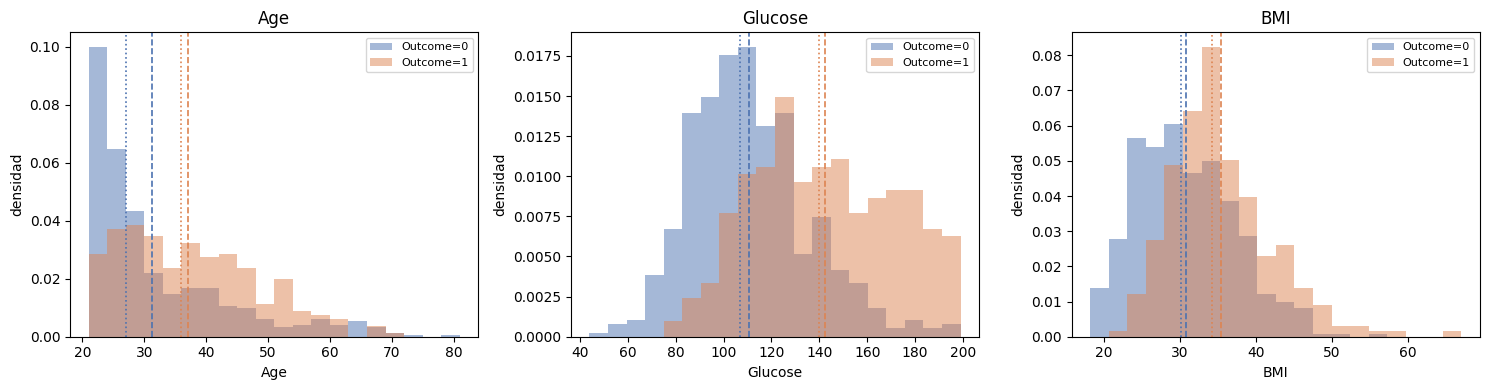

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = {0: '#4C72B0', 1: '#DD8452'}

for ax, var in zip(axes, vars_interes):
    bins = np.histogram_bin_edges(df[var], bins=20)  # mismos intervalos para ambos grupos
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        ax.hist(serie, bins=bins, density=True, alpha=0.5,
                label=f'Outcome={outcome}', color=colores[outcome])
        ax.axvline(serie.mean(), color=colores[outcome], linestyle='--', linewidth=1.2)
        ax.axvline(serie.median(), color=colores[outcome], linestyle=':', linewidth=1.2)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel('densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Resultados y evidencia:**

Los histogramas de densidad muestran, para las tres variables, que el grupo Outcome=1 (naranja) esta desplazado hacia la derecha respecto de Outcome=0 (azul): sus medias y medianas (lineas verticales) caen mas a la derecha. Glucose muestra la separacion visualmente mas clara entre los dos grupos; Age y BMI muestran mayor solapamiento en el centro de la distribucion, aunque las colas derechas del grupo 1 son mas densas.


## 11. Diagramas de caja y observaciones atípicas

### Investiga y responde

Construye un diagrama de caja por variable y compara ambos grupos. ¿Qué indica la caja? ¿Qué diferencias ves entre centros y amplitudes? Cuenta los valores exteriores a los límites de Tukey. ¿Los eliminarías automáticamente?

**Mi propuesta de procedimiento:**

Construimos un diagrama de caja por variable, con una caja para Outcome=0 y otra para Outcome=1. Contamos los puntos fuera de los limites de Tukey (Q1 - 1.5*IQR, Q3 + 1.5*IQR) con una mascara booleana sobre cada grupo.

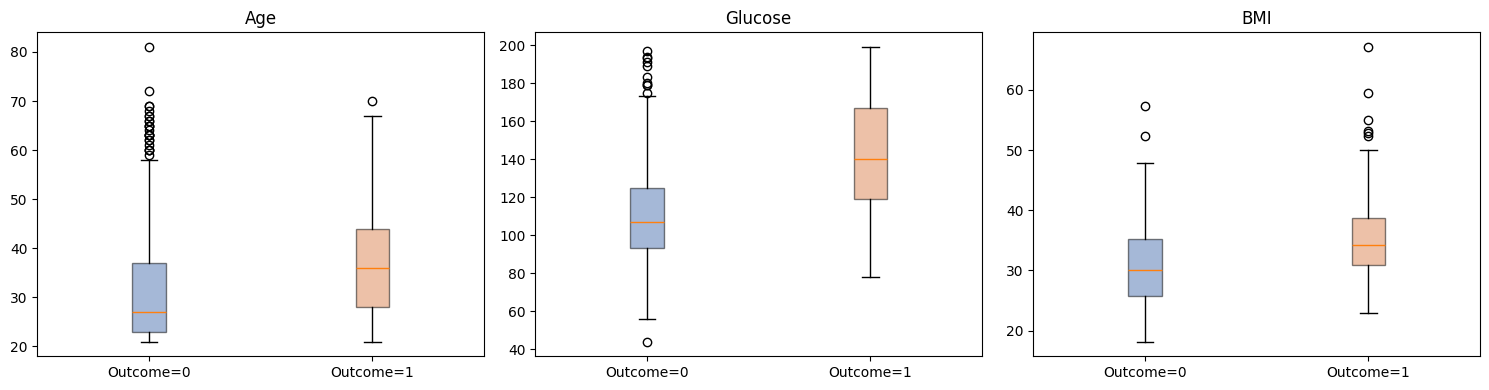

Observaciones fuera de los limites de Tukey (Q1 - 1.5*IQR, Q3 + 1.5*IQR):
Age | grupo 0: 24 valores atipicos (limites: 2.0 - 58.0)
Age | grupo 1: 1 valores atipicos (limites: 4.0 - 68.0)
Glucose | grupo 0: 11 valores atipicos (limites: 45.0 - 173.0)
Glucose | grupo 1: 0 valores atipicos (limites: 47.0 - 239.0)
BMI | grupo 0: 2 valores atipicos (limites: 11.4 - 49.6)
BMI | grupo 1: 6 valores atipicos (limites: 19.1 - 50.6)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, vars_interes):
    datos = [df[df['Outcome'] == 0][var], df[df['Outcome'] == 1][var]]
    bp = ax.boxplot(datos, tick_labels=['Outcome=0', 'Outcome=1'], patch_artist=True)
    for patch, color in zip(bp['boxes'], [colores[0], colores[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_title(var)

plt.tight_layout()
plt.show()

print("Observaciones fuera de los limites de Tukey (Q1 - 1.5*IQR, Q3 + 1.5*IQR):")
for var in vars_interes:
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        q1, q3 = serie.quantile([.25, .75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        atipicos = ((serie < lim_inf) | (serie > lim_sup)).sum()
        print(f"{var} | grupo {outcome}: {atipicos} valores atipicos (limites: {lim_inf:.1f} - {lim_sup:.1f})")


**Resultados y evidencia:**

| Variable | Grupo | Valores atipicos (Tukey) |
|---|---|---|
| Age | 0 | 24 |
| Age | 1 | 1 |
| Glucose | 0 | 11 |
| Glucose | 1 | 0 |
| BMI | 0 | 2 |
| BMI | 1 | 6 |



## 12. Integrar evidencia y comparar escalas

### Investiga y responde

Integra media, mediana, cuartiles y desviación estándar en una tabla. ¿Qué variable parece separar más los grupos? Justifica con centros y solapamiento. Como desafío opcional, investiga cómo estandarizar la diferencia sin mezclar unidades.

**Mi propuesta de procedimiento:**

Reunimos en una tabla la media, mediana, Q1, Q3 y desviacion estandar (ddof=0) por grupo y variable. Como desafio opcional, estandarizamos la diferencia de medias con la **d de Cohen**: `d = (media_1 - media_0) / desviacion_estandar_combinada`. Al dividir por una desviacion estandar, `d` queda en "unidades de dispersion" y es comparable entre variables con escalas distintas (años, mg/dL, kg/m2).

In [ ]:
resumen = []
for var in vars_interes:
    for outcome in [0, 1]:
        serie = df[df['Outcome'] == outcome][var]
        resumen.append({
            'variable': var, 'grupo': outcome,
            'media': round(serie.mean(), 2), 'mediana': round(serie.median(), 2),
            'Q1': round(serie.quantile(.25), 2), 'Q3': round(serie.quantile(.75), 2),
            'std (ddof=0)': round(serie.std(ddof=0), 2)
        })
tabla_resumen = pd.DataFrame(resumen)
print(tabla_resumen)
print()

print("Tamano de efecto estandarizado (d de Cohen):")
for var in vars_interes:
    g0 = df[df['Outcome'] == 0][var]
    g1 = df[df['Outcome'] == 1][var]
    n0, n1 = len(g0), len(g1)
    s0, s1 = g0.std(ddof=1), g1.std(ddof=1)
    sp = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
    d = (g1.mean() - g0.mean()) / sp
    print(f"{var}: d = {d:.3f}")


  variable  grupo   media  mediana      Q1      Q3  std (ddof=0)
0      Age      0   31.19     27.0   23.00   37.00         11.66
1      Age      1   37.07     36.0   28.00   44.00         10.95
2  Glucose      0  110.62    107.0   93.00  125.00         24.68
3  Glucose      1  142.30    140.0  119.00  167.00         29.43
4      BMI      0   30.85     30.1   25.75   35.30          6.50
5      BMI      1   35.40     34.3   30.90   38.78          6.58

Tamano de efecto estandarizado (d de Cohen):
Age: d = 0.514
Glucose: d = 1.197
BMI: d = 0.697


**Resultados y evidencia:**

| Variable | Grupo | Media | Mediana | Q1 | Q3 | Std (ddof=0) |
|---|---|---|---|---|---|---|
| Age | 0 | 31.19 | 27.0 | 23.00 | 37.00 | 11.66 |
| Age | 1 | 37.07 | 36.0 | 28.00 | 44.00 | 10.95 |
| Glucose | 0 | 110.62 | 107.0 | 93.00 | 125.00 | 24.68 |
| Glucose | 1 | 142.30 | 140.0 | 119.00 | 167.00 | 29.43 |
| BMI | 0 | 30.85 | 30.1 | 25.75 | 35.30 | 6.50 |
| BMI | 1 | 35.40 | 34.3 | 30.90 | 38.78 | 6.58 |

d de Cohen: Age ≈ 0.51, Glucose ≈ 1.20, BMI ≈ 0.70.


## 13. Formular hipótesis a partir de los hallazgos

### Investiga y responde

Formula una hipótesis para cada variable indicando grupo, dirección y medida. Escribe una hipótesis nula y una alternativa para glucosa. ¿Qué evidencia apoya tu propuesta? ¿Qué información faltaría para evaluar causalidad o riesgo futuro?

**Mi propuesta de procedimiento:**

Formulamos cada hipotesis como una afirmacion sobre las medias u medianas observadas en los datos disponibles, no sobre una poblacion general, indicando variable, grupo, direccion (mayor/menor) y la medida usada como evidencia.

**Resultados y evidencia:**

- **Edad:** en este dataset, la mediana de edad de las personas con Outcome=1 (36 años) es mayor que la del grupo Outcome=0 (27 años).
- **Glucosa:** en este dataset, la media de glucosa del grupo Outcome=1 (142.30) es mayor que la del grupo Outcome=0 (110.62), con la mayor separacion relativa entre las tres variables (d de Cohen ≈ 1.20).
- **IMC:** en este dataset, la mediana de IMC del grupo Outcome=1 (34.3) es mayor que la del grupo Outcome=0 (30.1).

**Hipotesis para glucosa:**
- H0 (nula): en la poblacion de la que proviene esta muestra, la media de glucosa no difiere entre personas con y sin diabetes (mu_glucosa,1 = mu_glucosa,0).
- H1 (alternativa): la media de glucosa de las personas con diabetes es mayor que la de las personas sin diabetes (mu_glucosa,1 > mu_glucosa,0).


## 14. Redactar una conclusión defendible

### Investiga y responde

Redacta entre 150 y 250 palabras. Incluye: tamaño de los grupos; dos comparaciones de centros; una medida de dispersión; evidencia gráfica de solapamiento; una hipótesis; y dos limitaciones. ¿Qué responderías a «la variable con mayor promedio genera diabetes»? ¿Qué nueva información pedirías antes de construir un predictor?

**Mi propuesta de procedimiento:**

La conclusion debe integrar la pregunta inicial, la evidencia numerica de las secciones anteriores, la evidencia grafica y los limites del analisis, evitando lenguaje causal.

**Resultados y evidencia / Conclusion (~200 palabras):**

Este analisis comparo edad, glucosa e IMC entre 500 registros con Outcome=0 y 268 registros con Outcome=1 en el archivo diabetes.csv. En los tres casos, el grupo Outcome=1 mostro centros mas altos: la mediana de edad paso de 27 a 36 años, y la media de glucosa de 110.6 a 142.3 mg/dL, esta ultima con la mayor separacion relativa (d de Cohen ≈ 1.20) frente a edad (≈0.51) e IMC (≈0.70). La dispersion tambien fue mayor en el grupo Outcome=1 para glucosa (desviacion estandar 29.4 frente a 24.7). Los histogramas de densidad y los diagramas de caja muestran, para las tres variables, una zona amplia de solapamiento entre grupos: ninguna variable separa a las personas de forma perfecta, y varios registros del grupo Outcome=0 superan la mediana del grupo Outcome=1.

A partir de esto proponemos, de forma exploratoria, que la glucosa esta asociada con Outcome=1 en esta muestra. Ante la afirmacion "la variable con mayor promedio genera diabetes", la respuesta es que estos datos muestran una **asociacion observacional**, no una relacion causal: no hubo manipulacion experimental ni control de otras variables. Dos limitaciones centrales: (1) el dataset no documenta unidades ni protocolo de medicion, y (2) no se puede generalizar a personas fuera de la muestra. Antes de construir un predictor pediriamos mas variables clinicas, una definicion verificada de Outcome y una muestra independiente para validar.

Haber tenido la ayuda de otra materia la cual apoyarme para hacer el ejercicio fue bastante aliviadora y apoyó bastante el no uso de la i.a para hacer la totalidad del documento. (Inteligencia Artificial es el nombre de la clase)